# Car Price Prediction


#### Project Workflow
1. Understand the Dataset
- Review all columns and their meanings (you’ve already done this — great start!)
- Identify which variables are:
- Independent (features)
- Dependent (target)

2. Clean and Prepare the Data
- Check for missing values or anomalies (e.g., nulls sales)
- Create new features if needed:

3. Explore the Data (EDA)
Use visualizations to uncover patterns:
- 📉 Boxplots to see sales distribution by weather or promotion
- 📌 Correlation heatmap to see which features influence sales most

4. Model Sales Drivers
- Use regression models (e.g., Linear Regression, Random Forest, XGBoost) to predict daily_sales
- Evaluate feature importance: which variables drive sales the most?
- Try time series models (e.g., ARIMA, Prophet) if you're forecasting future sales

7. Present Your Work
- Create a dashboard (Excel, Power BI, or Tableau)
- Summarize key insights in a slide deck or report
- Include visuals, trends, and actionable takeaways


In [1]:
# Importing Libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
#Importing Dataset
df = pd.read_csv('car_sales_data.csv')

raw_df = df.copy()

## Data Cleaning

In [3]:
df.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  object 
 1   Model                50000 non-null  object 
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  object 
 4   Year of manufacture  50000 non-null  int64  
 5   Mileage              50000 non-null  int64  
 6   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 2.7+ MB


In [5]:
df.describe()

,Engine size,Year of manufacture,Mileage,Price
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.773058,2004.209440,112497.320700,13828.903160
std,0.734108,9.645965,71632.515602,16416.681336
min,1.000000,1984.000000,630.000000,76.000000
25%,1.400000,1996.000000,54352.250000,3060.750000
50%,1.600000,2004.000000,100987.500000,7971.500000
75%,2.000000,2012.000000,158601.000000,19026.500000
max,5.000000,2022.000000,453537.000000,168081.000000


In [6]:
df.duplicated().sum()

12

In [7]:
df[df.duplicated()]

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
5426,VW,Polo,1.2,Petrol,2003,10000,8024
9862,Ford,Mondeo,1.4,Diesel,1987,224569,883
14745,BMW,Z4,2.4,Petrol,1999,12000,13410
19020,Toyota,Yaris,1.0,Petrol,1996,13500,5087
19337,VW,Polo,1.0,Petrol,2000,11500,5950
23927,VW,Polo,1.2,Petrol,2021,1000,27901
25368,VW,Golf,1.2,Diesel,2011,6000,17401
28576,VW,Polo,1.2,Petrol,2003,10000,8024
34246,VW,Passat,2.0,Diesel,2003,10000,16087
35647,Ford,Focus,1.6,Petrol,2019,2000,39636


In [8]:
# Handling Duplicates
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

0

In [10]:
df = df.reset_index(drop=True)

In [11]:
# Handling Missing Values
df.isnull().sum()

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

## EDA


✅ 1. Univariate Analysis (Quick Checks)
✔ Histograms / KDE plots for:
- Price
- Mileage
- Year of manufacture
- Engine size


✅ 2. Outlier Detection (Outliers can ruin models if not handled.)
Use: Boxplots, IQR, Scatterplots of Price vs key features
Look specifically for:
- Extremely old cars
- Very high mileage cars
- Price values too low or too high compared to the rest


✅ 3. Relationship Analysis (Minimal Pairwise Checks)
Only 3 scatterplots are needed:
- Price vs Mileage (declining trend?)
- Price vs Age/Year (strong expected relationship)
- Price vs Engine size (positive relationship)
Purpose:
Helps you see whether linear or non-linear models might work better, and where transformations may help.


✅ 4. Categorical Variable Insights
✔ View counts of: Manufacturer, Model, Fuel type
`df['Manufacturer'].value_counts()`
`df['Model'].value_counts()`
`df['Fuel type'].value_counts()`

Why this matters:
- Helps detect rare categories
- Helps decide which encoding to use
- Model will likely need target/frequency encoding
- Manufacturer/Fuel type → one-hot is fine


✅ 5. Multicollinearity Check (Optional but Recommended)

Mainly to avoid redundant variables:

- Year vs Car age (if you eventually create it)
- Engine size vs Engine category
- Mileage vs Mileage per year (after engineering)

For now, just check correlation among numerical columns


`NB: Do No7 after Completing Data Preprocessing and Feature Engineering`

### Univariate Analysis; To detect outliers and Skeweness
✔ Histograms / KDE and boxplots for:
- Price
- Mileage
- Year of manufacture
- Engine size

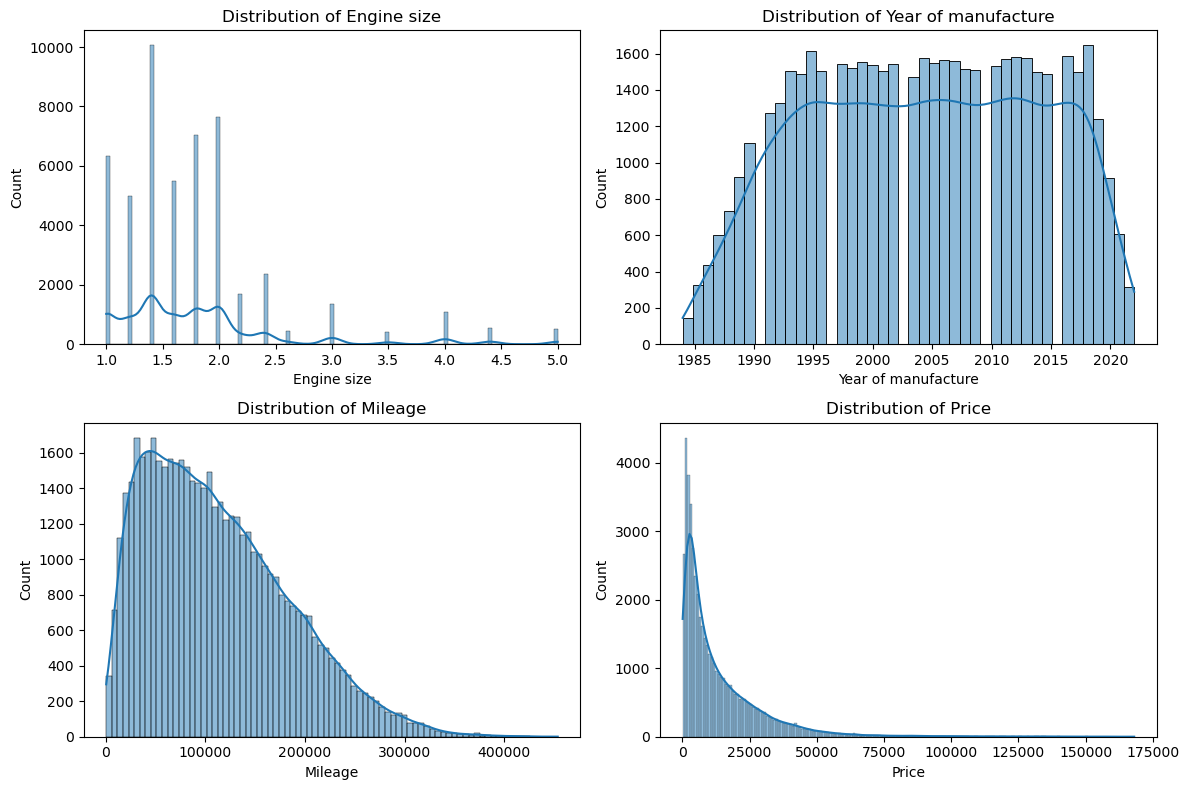

In [12]:
# Visualizing Histogram + KDE for numerical columns
numerical_features = ['Engine size', 'Year of manufacture', 'Mileage', 'Price']

plt.figure(figsize=(12, 8))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

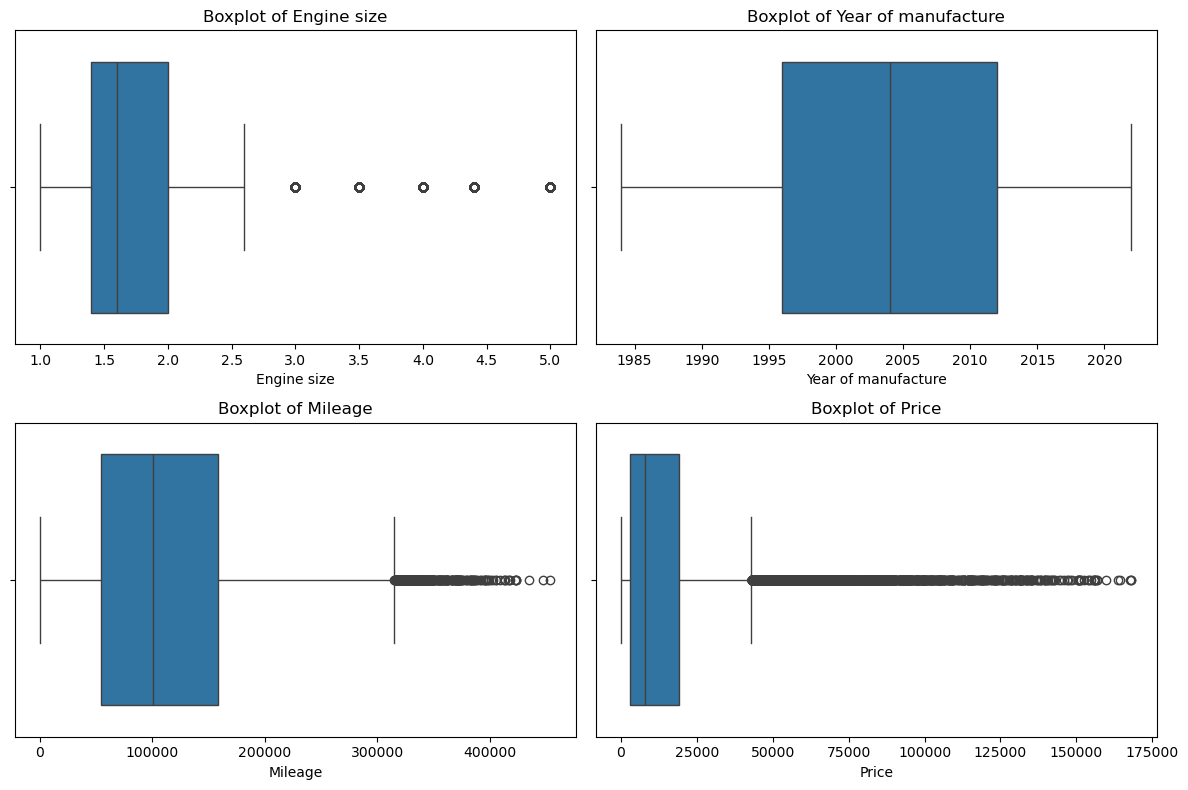

In [13]:
# Visualizing boxplots for numerical columns
numerical_features = ['Engine size', 'Year of manufacture', 'Mileage', 'Price']

plt.figure(figsize=(12, 8))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature}')

plt.tight_layout()
plt.show()


In [14]:
df[numerical_features].describe()

,Engine size,Year of manufacture,Mileage,Price
count,49988.000000,49988.000000,49988.000000,49988.000000
mean,1.773140,2004.209630,112515.561215,13829.112387
std,0.734149,9.646056,71624.341062,16417.812203
min,1.000000,1984.000000,630.000000,76.000000
25%,1.400000,1996.000000,54375.250000,3059.750000
50%,1.600000,2004.000000,101011.500000,7971.000000
75%,2.000000,2012.000000,158617.250000,19028.500000
max,5.000000,2022.000000,453537.000000,168081.000000


### Looking for Correlations

In [15]:
df.dtypes

Manufacturer            object
Model                   object
Engine size            float64
Fuel type               object
Year of manufacture      int64
Mileage                  int64
Price                    int64
dtype: object

In [16]:
corr_matrix = df[numerical_features].corr()

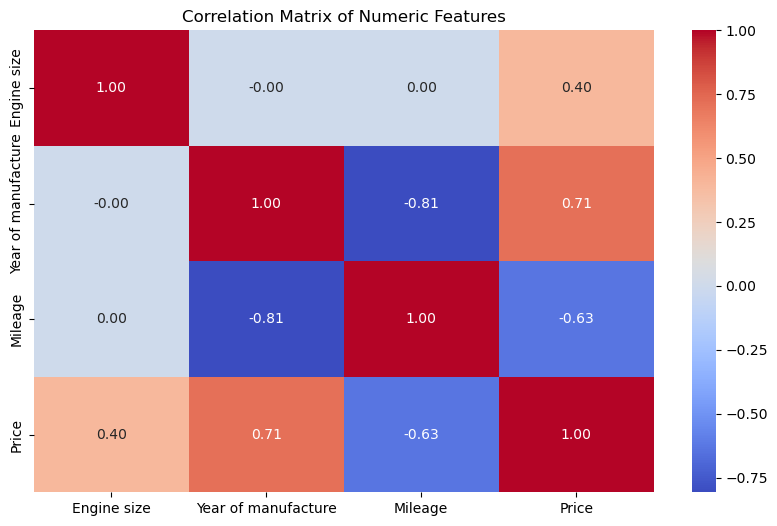

In [17]:
# Visualizing the correlation matrix using a heatmap

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

From the correlation matrix above;
- Year of manufacture has a strong direct proportionality to Prie
- Engine size is moderately directly proportional to price
- Mileage is Strongly Indirectly Proportional to the Price

In [18]:
df.head(10)

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101
5,Ford,Focus,1.4,Petrol,2018,33603,29204
6,Ford,Mondeo,1.8,Diesel,2010,86686,14350
7,Toyota,Prius,1.4,Hybrid,2015,30663,30297
8,VW,Polo,1.2,Petrol,2012,73470,9977
9,Ford,Focus,2.0,Diesel,1992,262514,1049


### Relationship / Multivariate Analysis


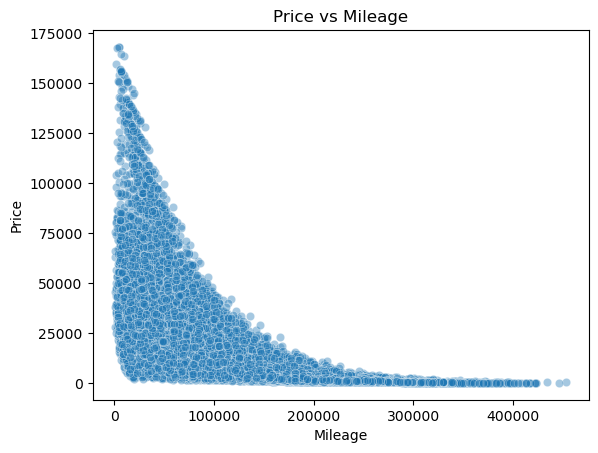

In [19]:
#Price vs Mileage Scatter Plot
sns.scatterplot(data=df, x="Mileage", y="Price", alpha=0.4)
plt.title('Price vs Mileage')
plt.show()

`Theres a downward trend i.e; the lower the milage the higher the price.`

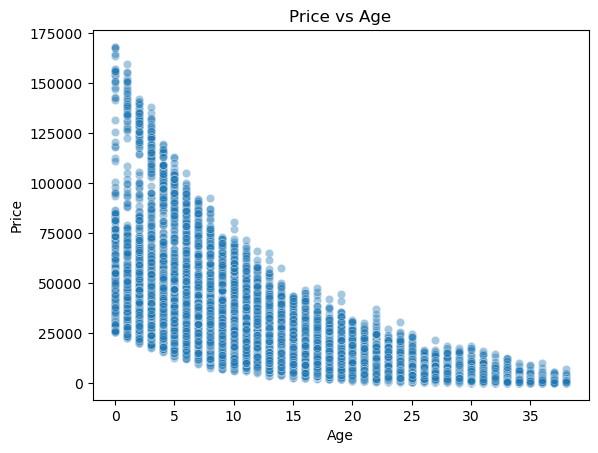

In [20]:
#Price vs Age Scatter Plot
#First create a new column 'Age' because Year of manufacture is not very intuitive
df['Age'] = 2022 - df['Year of manufacture'] #Assuming the current year is 2022


sns.scatterplot(data=df, x="Age", y="Price", alpha=0.4)
plt.title('Price vs Age')
plt.show()

`Theres a downward trend as well in the price vs Age i.e; the lower the older the age, lower the price.`

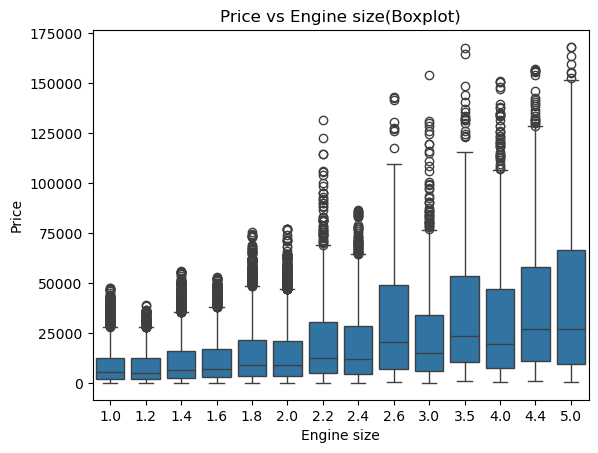

In [21]:
# Boxplot for Price vs Engine size
sns.boxplot(data=df, x="Engine size", y="Price")
plt.title("Price vs Engine size(Boxplot)")
plt.show()

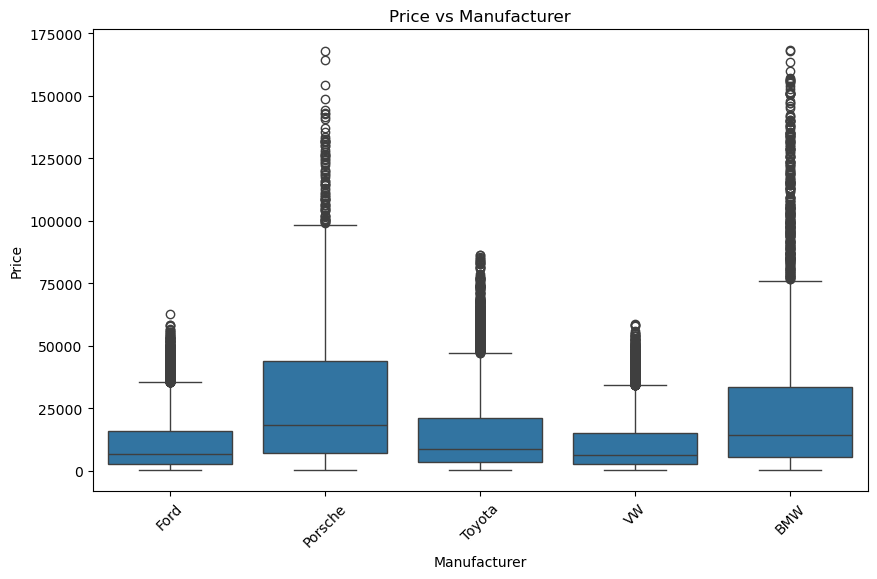

In [22]:
# Price vs Manufacturer Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Manufacturer", y="Price")
plt.xticks(rotation=45)
plt.title("Price vs Manufacturer")
plt.show()

`In order of price: Porsche > BMW > Toyota > Ford > VW`

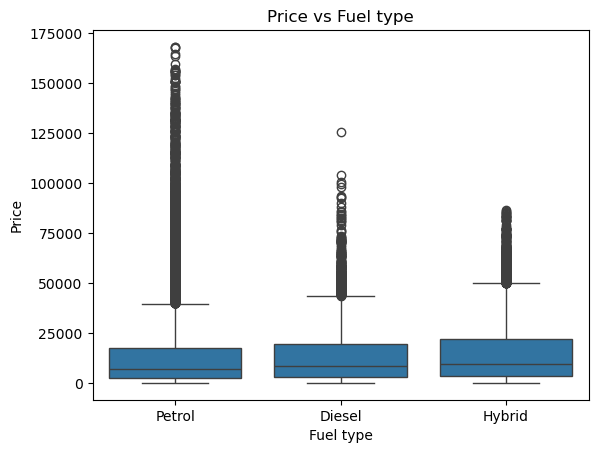

In [23]:
#Price vs Fuel type
sns.boxplot(data=df, x="Fuel type", y="Price")
plt.title("Price vs Fuel type")
plt.show()

`In order of price: Hybrid > Diesel > Petrol`

### Categorical Variable Insights
✔ View counts of: Manufacturer, Model, Fuel type
`df['Manufacturer'].value_counts()`
`df['Model'].value_counts()`
`df['Fuel type'].value_counts()`

Why this matters:
- Helps detect rare categories
- Helps decide which encoding to use
- Model will likely need target/frequency encoding
- Manufacturer/Fuel type → one-hot is fine

In [24]:
df['Manufacturer'].value_counts()


Manufacturer
Ford       14956
VW         14906
Toyota     12553
BMW         4964
Porsche     2609
Name: count, dtype: int64

In [25]:
print(df['Model'].value_counts())

Model
Mondeo        5057
Golf          5049
Polo          4988
Focus         4975
Fiesta        4924
Passat        4869
RAV4          4292
Prius         4171
Yaris         4090
Z4            1687
M5            1645
X3            1632
911            872
Cayenne        870
718 Cayman     867
Name: count, dtype: int64


In [26]:
df['Model'].unique()

array(['Fiesta', '718 Cayman', 'Mondeo', 'RAV4', 'Polo', 'Focus', 'Prius',
       'Golf', 'Z4', 'Yaris', '911', 'Passat', 'M5', 'Cayenne', 'X3'],
      dtype=object)

In [27]:

df['Fuel type'].value_counts()

Fuel type
Petrol    25480
Diesel    13264
Hybrid    11244
Name: count, dtype: int64

`NB: When performing encoding on the categorical colums in the Preprocessing steps;`

Manufacturer and Fuel type --> One-hot encoding 

Model --> Target encoding

`Also, Perform the Target encoding on the training set alone rather than on the whole daset so as to avoid feature leakage`

# Data Preprocessing

✅ 1. Essential Feature Engineering for Car Price Prediction

- Car Age (instead of using Year directly)
`df['Car_Age'] = current_year - df['Year of manufacture']`

- Mileage per Year (Usage Intensity). i.e A car with 150,000 km over 15 years is not the same as 150,000 km over 5 years.
`df['Mileage_per_Year'] = df['Mileage'] / df['Car_Age'].replace(0, 1)`

- Engine Size Category (optional binning)
You can create bins like:
Small: <1.4
Medium: 1.4–2.0
Large: >2.0
Or just standard binning:
`df['Engine_Category'] = pd.cut(df['Engine size'], bins=[0, 1.4, 2.0, 4.0], labels=['Small','Medium','Large'])`

- Log-transform the target (Price): Car prices are usually right-skewed. Applying log transformation stabilizes variance and reduces outlier impact
`df['Log_Price'] = np.log(df['Price'])`


✅ 2. Encoding Categorical Variables Properly
Thefore the ffg encoding is prefarable;
Manufacturer → One-hot encoding is fine.
Fuel Type → One-hot encoding works.
Model → This is tricky.


✅ 3. Interaction features (often useful)
Useful examples:
Engine size × Manufacturer
Engine size × Fuel type
Car age × Mileage

✅ 4. Remove or treat extreme outliers.
Before fitting the model:
-Remove cars priced at absurdly low or high values
- Remove mileage above the 99th percentile
- Remove cars older than 30 years if they skew the model

eg: Your dataset has a 1988 Toyota — that’s essentially a classic/vintage category and will distort the model.

## Feature Engineering
- Age
- Mileage per year
- Brand popularity

In [28]:
# We've donr the feature engineering for 'Age' column already in the EDA section
print(df['Age'])

0        20
1         6
2         8
3        34
4        16
         ..
49983     4
49984    19
49985     0
49986     6
49987    10
Name: Age, Length: 49988, dtype: int64


In [29]:
df['Mileage']

0        127300
1         57850
2         39190
3        210814
4        127869
          ...  
49983     28664
49984    105120
49985      4030
49986     26468
49987    109300
Name: Mileage, Length: 49988, dtype: int64

In [30]:
df['Mileage_per_year'] = df['Mileage'] / df['Age'].replace(0,1)
print(df['Mileage_per_year'])

0         6365.000000
1         9641.666667
2         4898.750000
3         6200.411765
4         7991.812500
             ...     
49983     7166.000000
49984     5532.631579
49985     4030.000000
49986     4411.333333
49987    10930.000000
Name: Mileage_per_year, Length: 49988, dtype: float64


In [31]:
brand_freq = df['Manufacturer'].value_counts(normalize=True)
df['Brand_popularity'] = df['Manufacturer'].map(brand_freq)


In [32]:
df['Brand_popularity']

0        0.299192
1        0.052193
2        0.299192
3        0.251120
4        0.298192
           ...   
49983    0.099304
49984    0.251120
49985    0.299192
49986    0.299192
49987    0.298192
Name: Brand_popularity, Length: 49988, dtype: float64

In [33]:
# Handling Missing Values
df.isna().sum()


Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
Age                    0
Mileage_per_year       0
Brand_popularity       0
dtype: int64

## Encoding Categorical Variables
- Manufacturer
- Fuel type
- Model (Target encoding to be done after splitting the dataset)

In [34]:
print(df['Manufacturer'].nunique())

print(df['Manufacturer'].unique())

5
['Ford' 'Porsche' 'Toyota' 'VW' 'BMW']


In [35]:
print(df['Model'].nunique())

print(df['Model'].unique())

15
['Fiesta' '718 Cayman' 'Mondeo' 'RAV4' 'Polo' 'Focus' 'Prius' 'Golf' 'Z4'
 'Yaris' '911' 'Passat' 'M5' 'Cayenne' 'X3']


In [36]:
print(df['Fuel type'].nunique())

print(df['Fuel type'].unique())

3
['Petrol' 'Diesel' 'Hybrid']


In [37]:
df.columns

Index(['Manufacturer', 'Model', 'Engine size', 'Fuel type',
       'Year of manufacture', 'Mileage', 'Price', 'Age', 'Mileage_per_year',
       'Brand_popularity'],
      dtype='object')

In [38]:
# Creating Dummy Variables for manufacturer and fuel type

### Transformation of numerical features
🔵 If the feature is moderately right-skewed → use Log Transformation
Use log when:

Values are positive only (no zeros, no negatives)

The tail is long but not extreme

Examples in your dataset:
✔ Price
✔ Mileage


🟢 If the feature is highly right-skewed → use Square Root or Cube Root

Use this when log is still not enough OR when there are many small values.

Works well for:
✔ Engine Size (mild skew but discrete peaks)
✔ Mileage (if log still leaves skew)


`NB After applying transformation, replot the histogram + KDE and boxplot to check if the features are still skewed. Also, remember that XGBoost model does not require transformation` 

In [39]:
# Log Transformation of the mildely skewed numerical features
#df['Price_log'] = np.log1p(df['Price'])
#df['Mileage_log'] = np.log1p(df['Mileage'])

#--------------------------
#sqrt or cube root transformation 
#df['Mileage_sqrt'] = np.sqrt(df['Mileage'])


In [40]:
print(df['Engine size'].nunique())

print(df['Engine size'].unique())

14
[1.  4.  1.6 1.8 1.4 1.2 2.  2.2 2.4 2.6 3.5 4.4 3.  5. ]


### Multicollinearity Check (To be done after the Preprocessing step)

Mainly to avoid redundant variables:

- Year vs Car age (if you eventually create it)
- Engine size vs Engine category
- Mileage vs Mileage per year (after engineering)

For now, just check correlation among numerical columns

# Train / Test Split

# Build the Model
